In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
import nest_asyncio
nest_asyncio.apply()

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
df = pd.read_csv('/home/vivek/Documents/territory_geometry/processed_data/stability_ALL.csv')
df.head()

,lek_id,date_prev,date_now,centroid_shift,mode_shift,nn_cross_median,nn_cross_mean,nn_cross_cv
0,TalChhapar_TC,2012-10-01,2014-02-01,14.345197,25.195197,3.033985,6.864682,1.341986
1,TalChhapar_TC,2014-02-01,2015-11-01,19.180344,44.531731,5.317716,9.612448,1.142450
2,TalChhapar_TC,2015-11-01,2015-12-01,5.288125,33.362349,1.149035,4.630130,1.725009
3,TalChhapar_TC,2015-12-01,2018-01-01,62.661803,27.941469,10.504549,24.557366,1.565752
4,TalChhapar_TC,2018-01-01,2018-11-01,30.013742,65.168473,6.443491,12.524062,1.367217


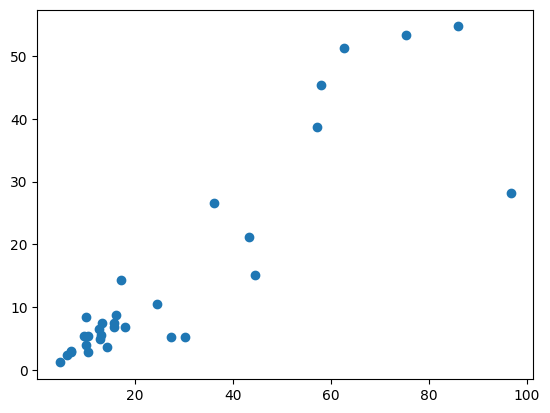

In [3]:
plt.scatter(df['nn_cross_mean'], df['nn_cross_median'])

In [4]:
crossyear_nnd = """
data {
    int<lower=1> N;
    vector[N] t;
    vector<lower=0>[N] y;
}
parameters {
    real alpha;
    real beta;
    real<lower=0> sigma;
}
transformed parameters {
}
model {
    y ~ normal(alpha + beta * t, sigma)
}
"""

data = {
    'N': len(df), 
    't': df.nn_cross_mean, 
    'y': df.nn_cross_median
}

posterior = stan.build(crossyear_nnd, data=data)
fit = posterior.sample(num_chains=4, num_samples=1000)

TypeError: Object of type Series is not JSON serializable

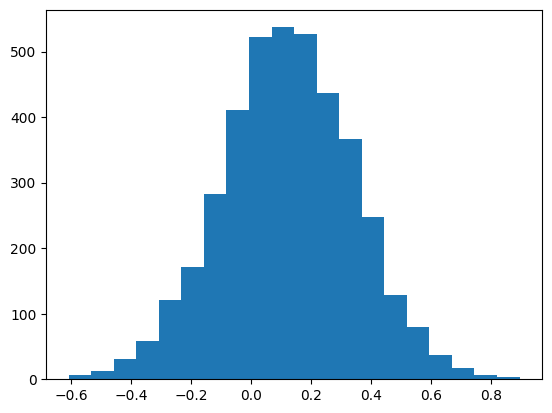

In [9]:
plt.hist(fit['mu'][0], bins=20)
plt.show()